In [80]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import seaborn as sns
import numpy as np
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

In [81]:
df = pd.read_csv('wdbc.data')
df.head(5)

,842302,M,17.99,10.38,122.8,1001,0.1184,0.2776,0.3001,0.1471,...,25.38,17.33,184.6,2019,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189
0,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
1,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
2,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
3,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
4,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.1578,0.08089,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440


In [82]:
df.shape

(568, 32)

In [83]:
df.columns

Index(['842302', 'M', '17.99', '10.38', '122.8', '1001', '0.1184', '0.2776',
       '0.3001', '0.1471', '0.2419', '0.07871', '1.095', '0.9053', '8.589',
       '153.4', '0.006399', '0.04904', '0.05373', '0.01587', '0.03003',
       '0.006193', '25.38', '17.33', '184.6', '2019', '0.1622', '0.6656',
       '0.7119', '0.2654', '0.4601', '0.1189'],
      dtype='object')

In [84]:
new_columns = [
    'id', 'diagnosis',
    'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean',
    'compactness_mean', 'concavity_mean', 'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean',
    'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
    'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se', 'fractal_dimension_se',
    'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst',
    'compactness_worst', 'concavity_worst', 'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst'
]

df.columns = new_columns
df.head(5)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
1,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
2,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
3,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
4,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.1578,0.08089,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440


In [85]:
df.isnull().sum().sum()

np.int64(0)

In [86]:
df['diagnosis'].value_counts()

,count
diagnosis,
B,357
M,211


In [87]:
df['diagnosis'] =  df['diagnosis'].map({'M':1,'B':0})
df['diagnosis'].value_counts()

,count
diagnosis,
0,357
1,211


## 1. Exploratory Data Analysis (EDA)

In [88]:
# Check for duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

if duplicate_rows > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicate rows removed.")
    print(f"New DataFrame shape: {df.shape}")

Number of duplicate rows: 0


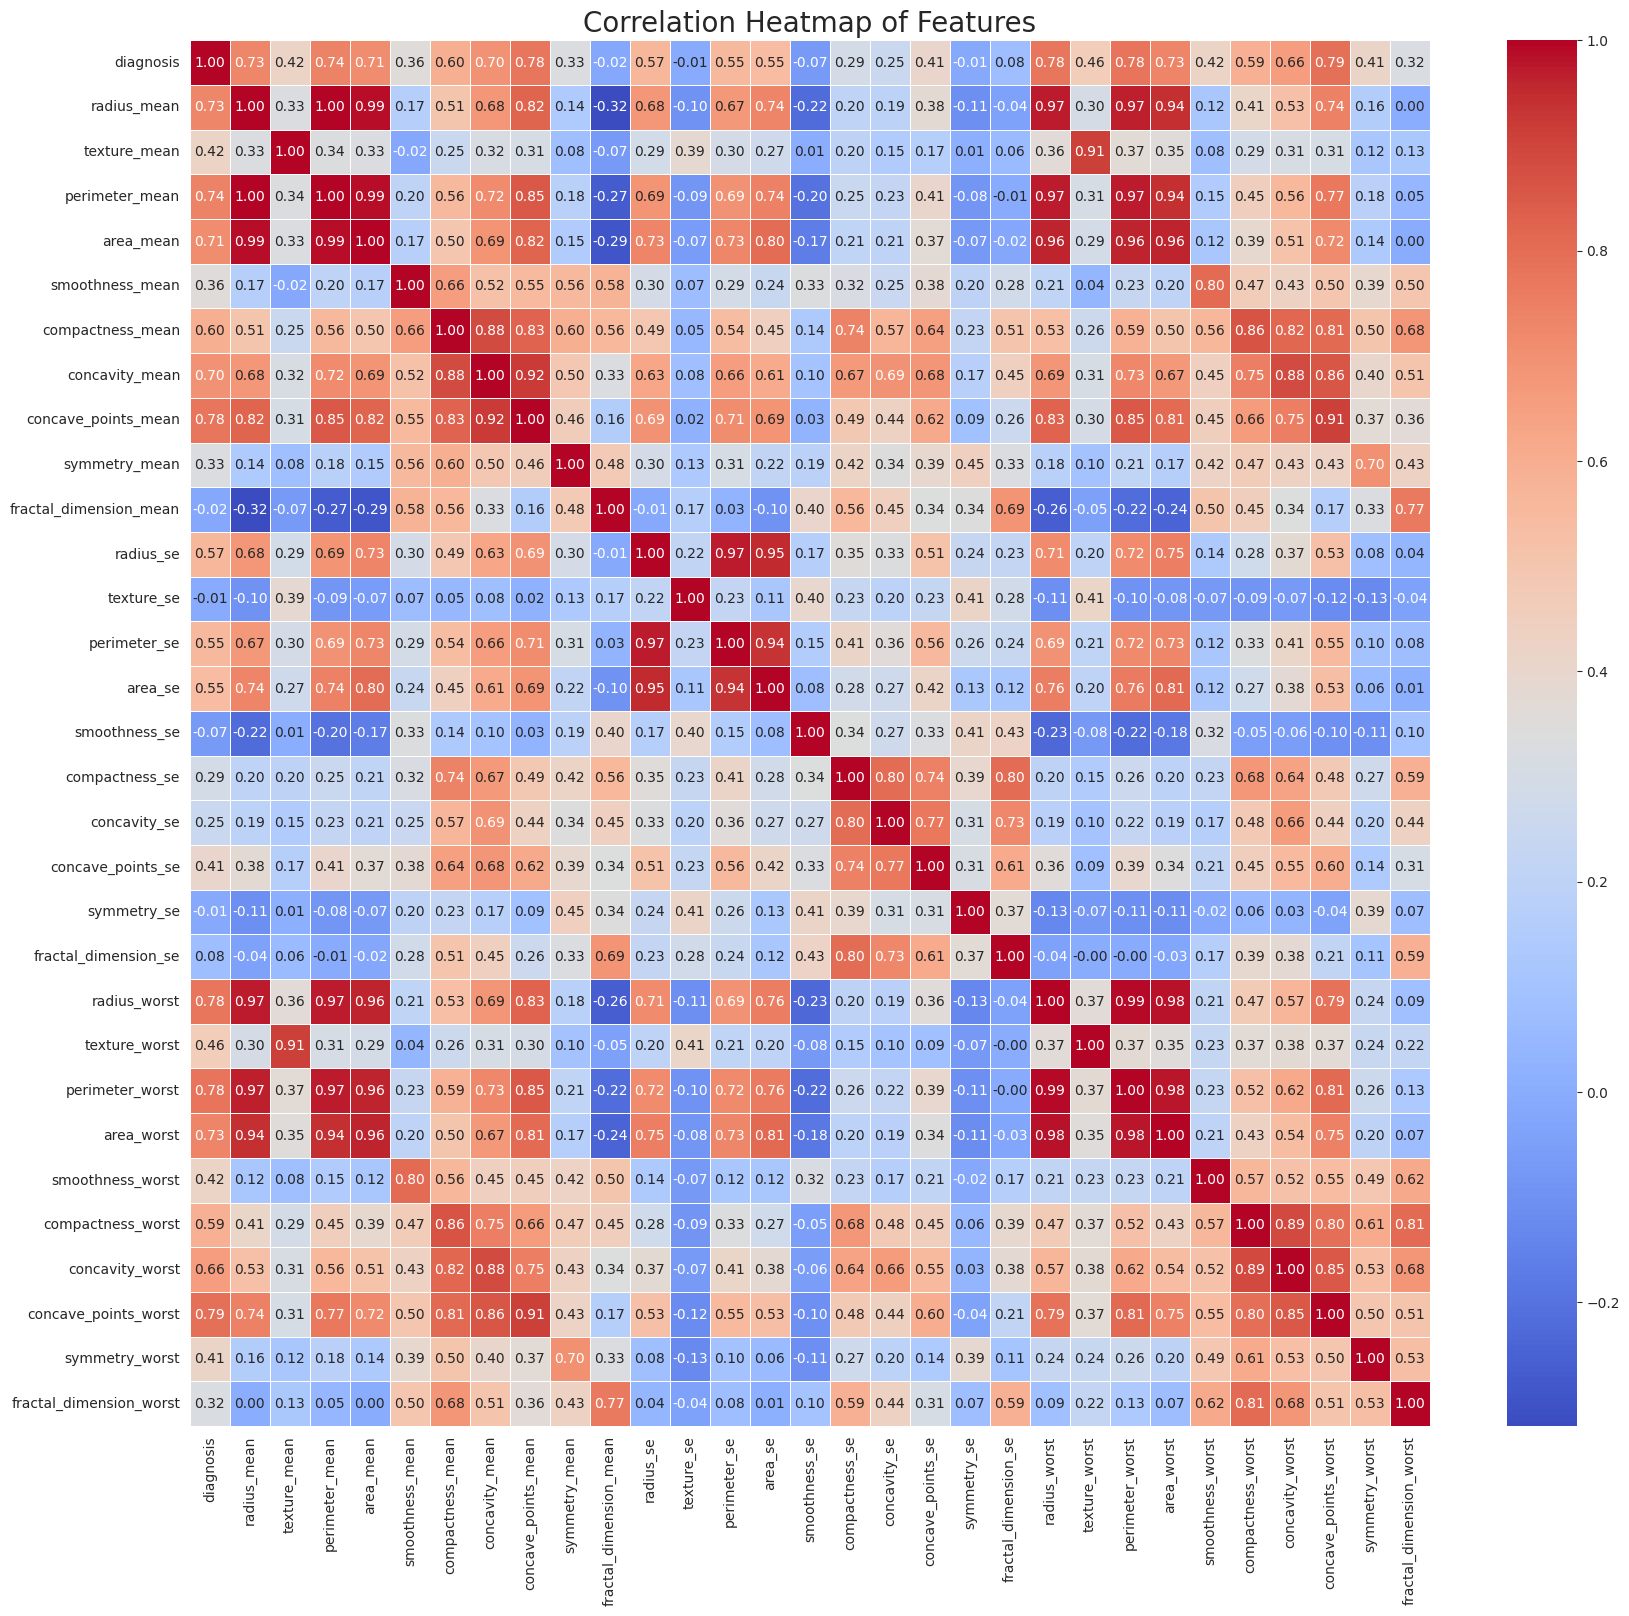


Feature pairs with correlation coefficient > 0.90:

texture_worst and texture_mean: 0.91
area_se and radius_se: 0.95
concave_points_mean and concavity_mean: 0.92
area_worst and area_mean: 0.96
area_worst and radius_mean: 0.94
perimeter_worst and radius_mean: 0.97
radius_worst and area_mean: 0.96
perimeter_mean and radius_mean: 1.00
perimeter_worst and area_mean: 0.96
concave_points_worst and concave_points_mean: 0.91
radius_worst and radius_mean: 0.97
area_mean and perimeter_mean: 0.99
area_worst and perimeter_worst: 0.98
perimeter_worst and perimeter_mean: 0.97
perimeter_worst and radius_worst: 0.99
area_worst and perimeter_mean: 0.94
radius_worst and perimeter_mean: 0.97
perimeter_se and radius_se: 0.97
area_mean and radius_mean: 0.99
area_worst and radius_worst: 0.98
area_se and perimeter_se: 0.94


In [89]:
# Plotting a correlation heatmap
plt.figure(figsize=(20, 18))
# Calculate the correlation matrix for all features except 'id'
corr_matrix = df.drop('id', axis=1).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Features', fontsize=20)
plt.show()

# Identify highly correlated feature pairs (correlation > 0.90)
highly_correlated_features = set()
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.90:
            colname1 = corr_matrix.columns[i]
            colname2 = corr_matrix.columns[j]
            highly_correlated_features.add((colname1, colname2, corr_matrix.iloc[i,j]))

print("\nFeature pairs with correlation coefficient > 0.90:\n")
if highly_correlated_features:
    for feature_pair in highly_correlated_features:
        print(f"{feature_pair[0]} and {feature_pair[1]}: {feature_pair[2]:.2f}")
else:
    print("No feature pairs found with correlation coefficient > 0.90.")

## 2. Feature Engineering & Selection

In [96]:
# 1. Drop the 'id' column as it is irrelevant for modeling
df_eda = df.drop("id", axis=1)

# 2. Calculate the absolute correlation matrix for all variables (including the target 'diagnosis')
full_corr_matrix = df_eda.corr().abs()

# Extract features only for the multicollinearity check
features = df_eda.drop(columns=["diagnosis"])
corr_matrix_features = features.corr().abs()

# Select upper triangle of feature correlation matrix to avoid duplicate pairs
upper_tri = corr_matrix_features.where(
    np.triu(np.ones(corr_matrix_features.shape), k=1).astype(bool)
)

# 3. Identify highly correlated pairs and choose which one to drop based on target correlation
to_drop = set()
threshold = 0.90

for col in upper_tri.columns:
    # Find all features that have a correlation > 0.90 with the current 'col'
    high_corr_features = upper_tri.index[upper_tri[col] > threshold].tolist()

    for feature in high_corr_features:
        # Compare their individual correlation with the target variable ('diagnosis')
        corr_with_target_col = full_corr_matrix.loc[col, "diagnosis"]
        corr_with_target_feature = full_corr_matrix.loc[feature, "diagnosis"]

        # Drop the feature that has a LOWER correlation with the target
        if corr_with_target_col < corr_with_target_feature:
            to_drop.add(col)
        else:
            to_drop.add(feature)

# Convert set to list for dropping
to_drop = list(to_drop)

# 4. Drop the identified columns from df_eda
df_selected_features = df_eda.drop(columns=to_drop)

# 5. Print the evaluation results
print(f"Features dropped due to high multicollinearity (> {threshold}) "
      f"and lower target correlation\n: {to_drop}\n")
print("Columns remaining after feature selection:")
print(df_selected_features.columns.tolist())
print(f"\nNew DataFrame shape: {df_selected_features.shape}")

Features dropped due to high multicollinearity (> 0.9) and lower target correlation
: ['perimeter_mean', 'concave_points_mean', 'area_mean', 'radius_mean', 'texture_mean', 'area_se', 'radius_worst', 'concavity_mean', 'perimeter_se', 'area_worst']

Columns remaining after feature selection:
['diagnosis', 'smoothness_mean', 'compactness_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se', 'fractal_dimension_se', 'texture_worst', 'perimeter_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst']

New DataFrame shape: (568, 21)


In [91]:
df_selected_features.head(5)

,diagnosis,smoothness_mean,compactness_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,smoothness_se,compactness_se,concavity_se,...,symmetry_se,fractal_dimension_se,texture_worst,perimeter_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,1,0.08474,0.07864,0.1812,0.05667,0.5435,0.7339,0.005225,0.01308,0.01860,...,0.01389,0.003532,23.41,158.80,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
1,1,0.10960,0.15990,0.2069,0.05999,0.7456,0.7869,0.006150,0.04006,0.03832,...,0.02250,0.004571,25.53,152.50,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
2,1,0.14250,0.28390,0.2597,0.09744,0.4956,1.1560,0.009110,0.07458,0.05661,...,0.05963,0.009208,26.50,98.87,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
3,1,0.10030,0.13280,0.1809,0.05883,0.7572,0.7813,0.011490,0.02461,0.05688,...,0.01756,0.005115,16.67,152.20,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
4,1,0.12780,0.17000,0.2087,0.07613,0.3345,0.8902,0.007510,0.03345,0.03672,...,0.02165,0.005082,23.75,103.40,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440


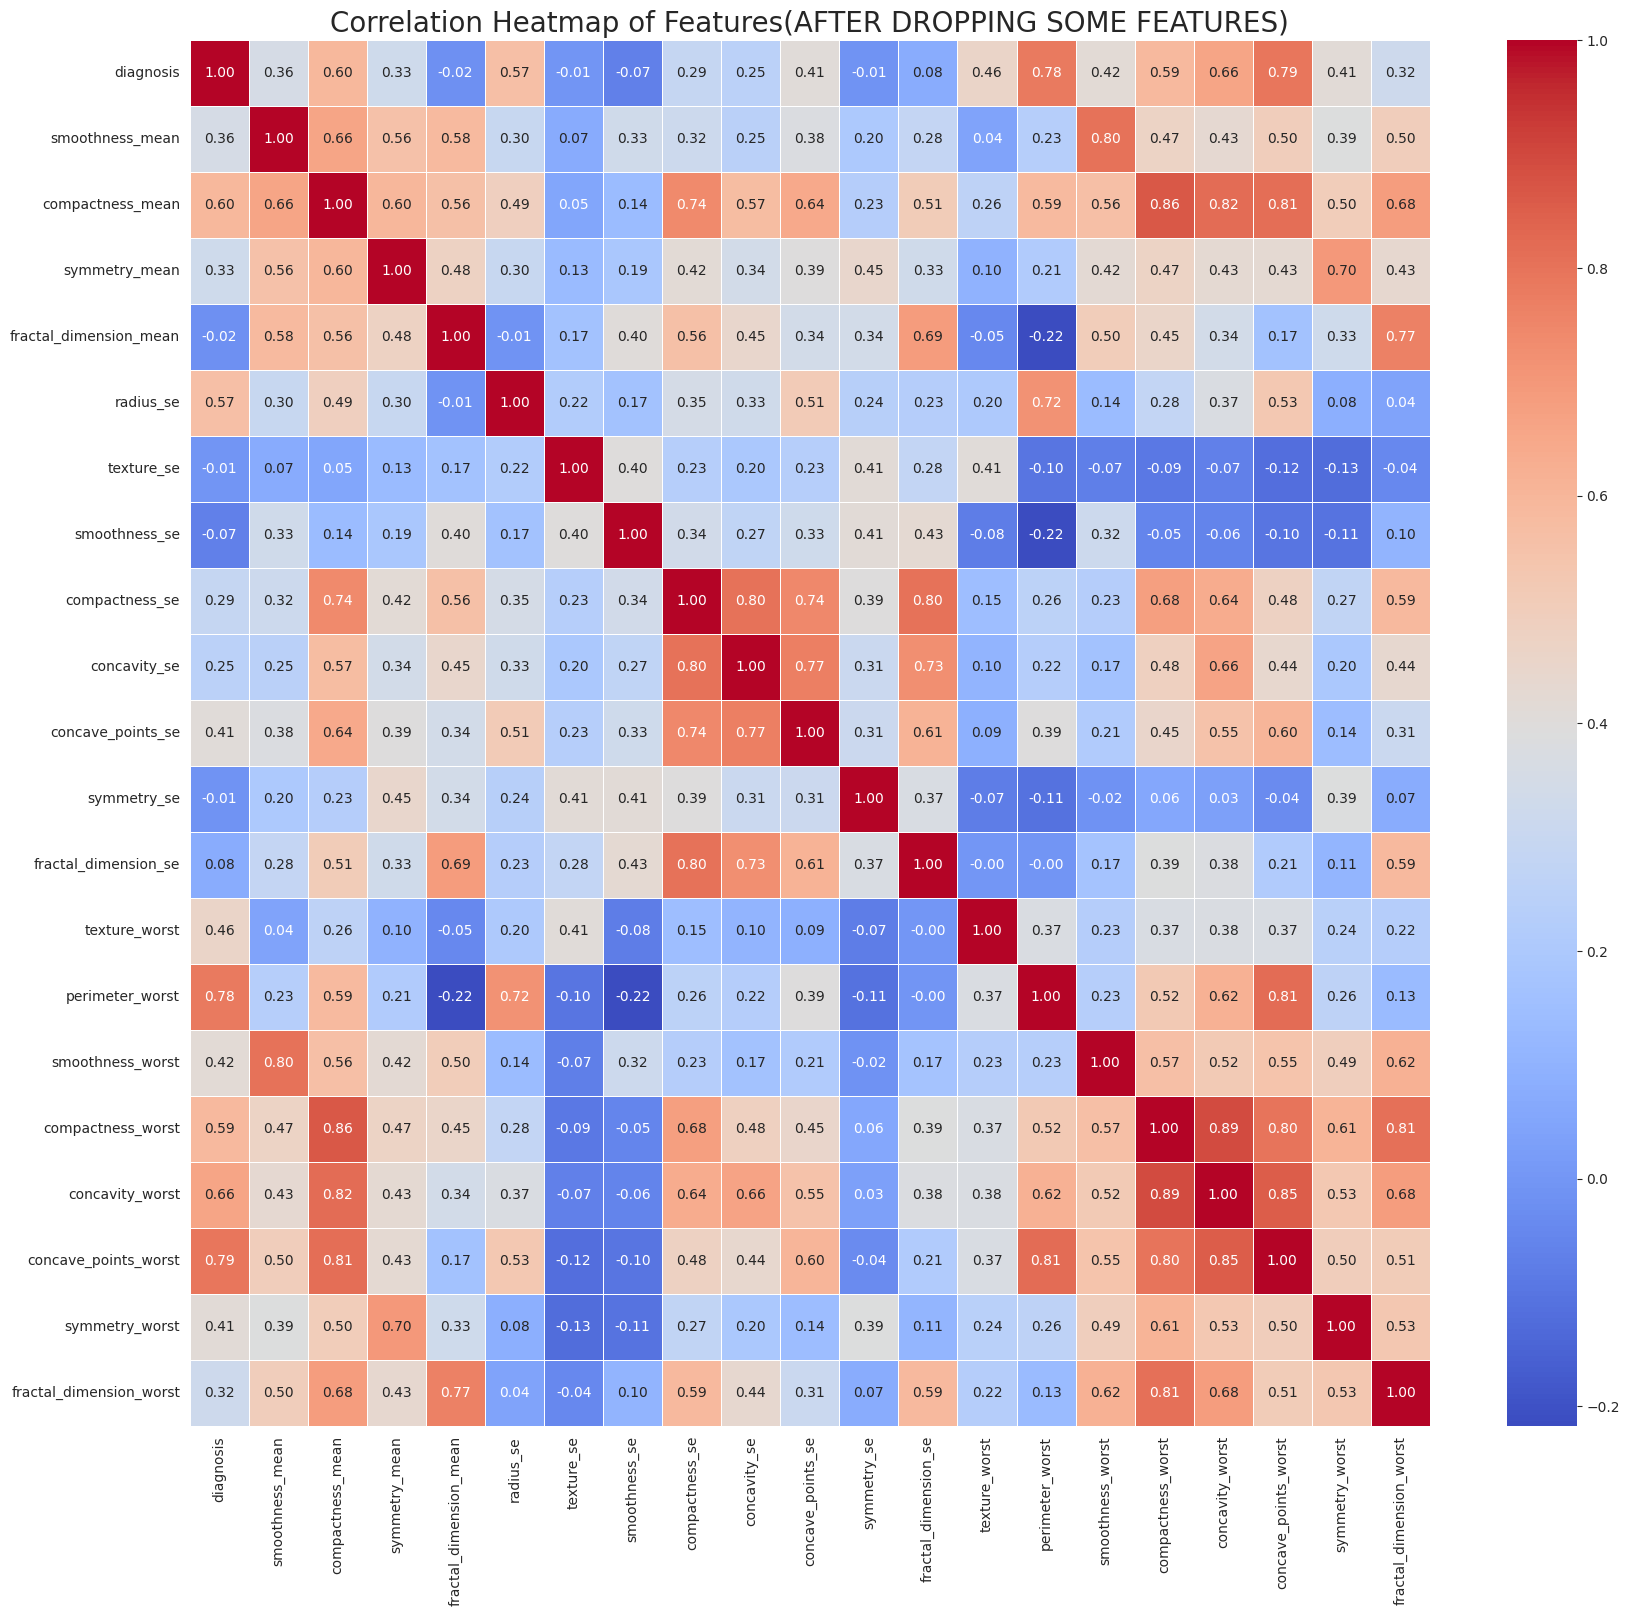

In [92]:
# Plotting a correlation heatmap
plt.figure(figsize=(20, 18))
# Calculate the correlation matrix for all features
corr_matrix = df_selected_features.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Features(AFTER DROPPING SOME FEATURES)', fontsize=20)
plt.show()

## 3. Train-Test Split

In [93]:
from sklearn.model_selection import train_test_split

# Split features (X) and target (y)
X = df_selected_features.drop('diagnosis', axis=1)
y = df_selected_features['diagnosis']

# Perform a stratified train-test split (80% train, 20% test)
# Stratify ensures that the proportion of target classes is similar in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("\nClass distribution in original dataset:")
print(y.value_counts(normalize=True))
print("\nClass distribution in y_train:")
print(y_train.value_counts(normalize=True))
print("\nClass distribution in y_test:")
print(y_test.value_counts(normalize=True))

X_train shape: (454, 20)
X_test shape: (114, 20)
y_train shape: (454,)
y_test shape: (114,)

Class distribution in original dataset:
diagnosis
0    0.628521
1    0.371479
Name: proportion, dtype: float64

Class distribution in y_train:
diagnosis
0    0.627753
1    0.372247
Name: proportion, dtype: float64

Class distribution in y_test:
diagnosis
0    0.631579
1    0.368421
Name: proportion, dtype: float64


## 4. Feature Scaling

In [94]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data ONLY to prevent data leakage
X_train_scaled = scaler.fit_transform(X_train)

# Transform both the training and test data using the fitted scaler
X_test_scaled = scaler.transform(X_test)

# Convert the scaled arrays back to DataFrames with original column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Features have been scaled. Here are the first 5 rows of X_train_scaled:")
display(X_train_scaled.head())

Features have been scaled. Here are the first 5 rows of X_train_scaled:


,smoothness_mean,compactness_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,smoothness_se,compactness_se,concavity_se,concave_points_se,symmetry_se,fractal_dimension_se,texture_worst,perimeter_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
462,-0.776676,-0.844715,-1.070366,-0.597984,-0.788071,-0.829111,-0.100624,-0.473890,-0.364936,-0.692000,0.091113,-0.386707,-0.296422,-0.733712,0.096593,-0.459964,-0.415609,-0.484295,0.547499,-0.286685
169,0.480641,-0.633632,0.532987,-0.459893,-0.599096,-1.007901,0.364722,-0.757834,-0.488498,0.095898,-0.147674,-0.581842,-1.686687,-0.604618,0.283361,-0.800024,-0.708574,-0.316470,-0.095554,-0.893061
238,0.148574,0.490960,-0.009909,-0.444071,0.445129,-0.667305,-0.744654,0.116888,-0.202469,0.309191,-0.981043,-0.390084,3.162652,1.027266,0.196492,0.749067,0.239057,1.398143,-0.051901,0.064814
423,0.814129,-0.380181,2.628564,1.084996,1.000590,0.925540,2.114993,-0.373610,-0.824917,-0.207201,1.256396,0.160047,-0.437439,-1.061413,0.339826,-0.746066,-1.198507,-1.047109,0.523993,-0.205613
29,0.736078,1.595118,1.343711,-0.111790,1.466774,0.423139,-0.261196,0.437891,0.604886,-0.037209,-0.048577,0.285759,1.360948,1.608039,0.743767,1.076579,1.610017,1.066449,0.940382,0.778916


The `X_train_scaled`, `X_test_scaled`, `y_train`, and `y_test` datasets are now ready for training classification algorithms.

## Saving Processed Data to CSV

In [95]:
# Save X_train_scaled to CSV
X_train_scaled.to_csv('X_train_scaled.csv', index=False)
print("X_train_scaled.csv saved successfully.")

# Save X_test_scaled to CSV
X_test_scaled.to_csv('X_test_scaled.csv', index=False)
print("X_test_scaled.csv saved successfully.")

# Save y_train to CSV
y_train.to_csv('y_train.csv', index=False)
print("y_train.csv saved successfully.")

# Save y_test to CSV
y_test.to_csv('y_test.csv', index=False)
print("y_test.csv saved successfully.")

X_train_scaled.csv saved successfully.
X_test_scaled.csv saved successfully.
y_train.csv saved successfully.
y_test.csv saved successfully.
